<a href="https://colab.research.google.com/github/dsb4k8/scipi-utils-exploration/blob/main/Copy_of_SimulatedAnnealing_via_library.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is an exploration of the student assignment class preference optimization problem I implemented over a decade ago in c++ - this time using modern libraries. Similar to the previous implementaion, ill use Simulated Annealing for this descrete optimization task.

Imports

In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment

Student Generation

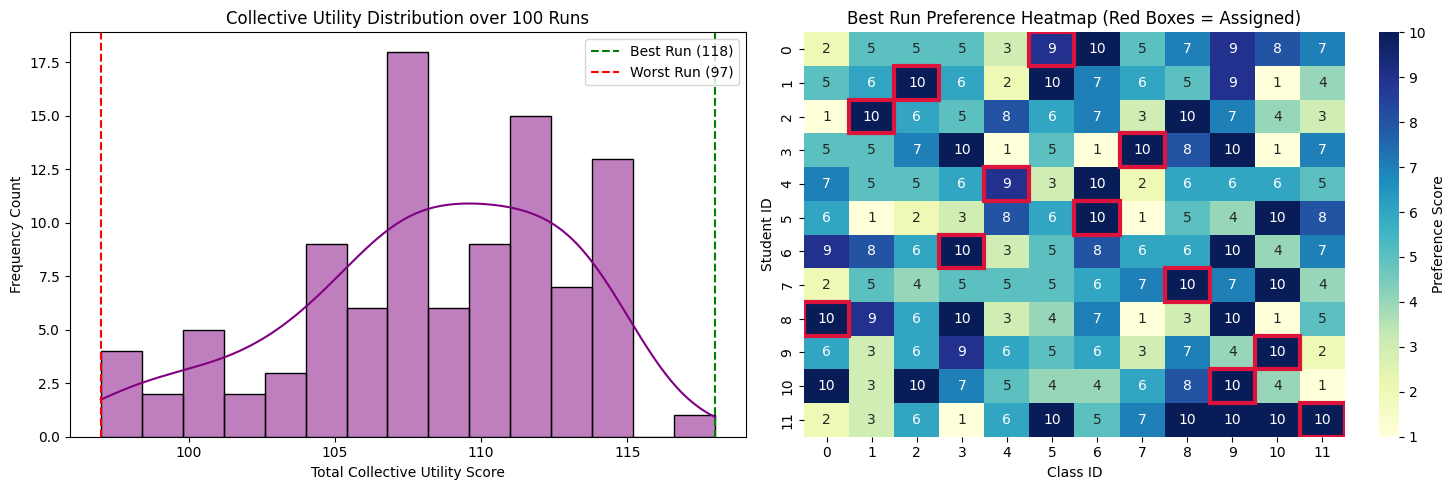

Simulation completed for 100 runs.
-> Highest Collective Satisfaction: 118 points (Run #98)
-> Lowest Collective Satisfaction: 97 points (Run #22)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

def generate_student_preferences(n_students, n_classes, max_score=10):
    """Generates a realistic student preference matrix with common popularity trends."""
    class_popularity = np.random.uniform(low=3.0, high=max_score - 2.0, size=n_classes)
    preferences = []
    for _ in range(n_students):
        student_noise = np.random.normal(loc=0.0, scale=3.0, size=n_classes)
        student_pref = np.clip(class_popularity + student_noise, 1, max_score)
        preferences.append(np.round(student_pref).astype(int))
    return np.array(preferences)

def run_simulation(n_runs=100, n_students=10, n_classes=10, max_score=10):
    """Runs the assignment pipeline multiple times and tracks utility tracking data."""
    all_utilities = []
    run_data = []

    for run_id in range(n_runs):
        prefs = generate_student_preferences(n_students, n_classes, max_score)
        cost_matrix = max_score - prefs
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        # Calculate total utility for this run
        total_utility = prefs[row_ind, col_ind].sum()
        all_utilities.append(total_utility)

        # Store data for deep-dive analysis
        run_data.append({
            'preferences': prefs,
            'assignments': (row_ind, col_ind),
            'total_utility': total_utility
        })

    return all_utilities, run_data

# ==========================================
# CONFIGURATION & EXECUTION
# ==========================================
NUM_RUNS = 100
N_STUDENTS = 12
N_CLASSES = 12
MAX_SCORE = 10

utilities, datasets = run_simulation(NUM_RUNS, N_STUDENTS, N_CLASSES, MAX_SCORE)

# Find the best and worst runs based on collective utility
best_run_idx = np.argmax(utilities)
worst_run_idx = np.argmin(utilities)

# ==========================================
# VISUALIZATION BLOCK
# ==========================================
plt.figure(figsize=(15, 5))

# Plot 1: Performance Distribution over all runs
plt.subplot(1, 2, 1)
sns.histplot(utilities, kde=True, color='purple', bins=15)
plt.axvline(utilities[best_run_idx], color='green', linestyle='--', label=f"Best Run ({utilities[best_run_idx]})")
plt.axvline(utilities[worst_run_idx], color='red', linestyle='--', label=f"Worst Run ({utilities[worst_run_idx]})")
plt.title(f"Collective Utility Distribution over {NUM_RUNS} Runs")
plt.xlabel("Total Collective Utility Score")
plt.ylabel("Frequency Count")
plt.legend()

# Plot 2: Deep Dive into the "Best Run" Matchings
plt.subplot(1, 2, 2)
best_prefs = datasets[best_run_idx]['preferences']
best_rows, best_cols = datasets[best_run_idx]['assignments']

# Generate a mask layer to visually mark where the algorithm placed students
assignment_mask = np.zeros_like(best_prefs, dtype=bool)
assignment_mask[best_rows, best_cols] = True

# Draw heatmap of preferences, highlighting chosen assignments with distinct borders
sns.heatmap(best_prefs, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Preference Score'}, fmt="d")
for r, c in zip(best_rows, best_cols):
    plt.gca().add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor='crimson', lw=3))

plt.title(f"Best Run Preference Heatmap (Red Boxes = Assigned)")
plt.xlabel("Class ID")
plt.ylabel("Student ID")

plt.tight_layout()
plt.show()

# Print text summary
print(f"Simulation completed for {NUM_RUNS} runs.")
print(f"-> Highest Collective Satisfaction: {utilities[best_run_idx]} points (Run #{best_run_idx})")
print(f"-> Lowest Collective Satisfaction: {utilities[worst_run_idx]} points (Run #{worst_run_idx})")


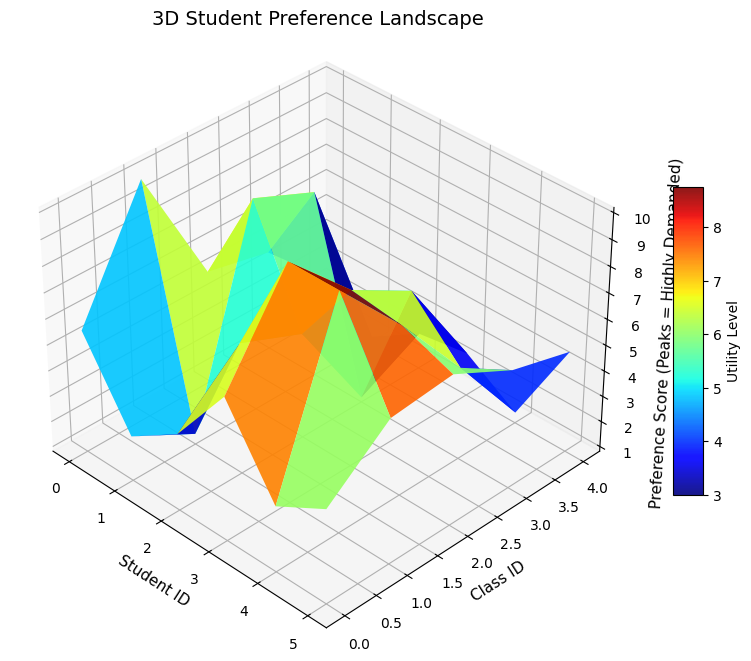

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Generate sample matching matrix data (12 students, 12 classes)
n_students, n_classes = 6, 5
np.random.seed(42) # Seeded for reproducible peaks
class_popularity = np.random.uniform(3, 8, size=n_classes)
prefs = np.array([np.clip(class_popularity + np.random.normal(0, 2.5, n_classes), 1, 10) for _ in range(n_students)])

# 2. Build grid alignments for 3D bar graphing or surface mapping
X, Y = np.meshgrid(np.arange(n_students), np.arange(n_classes))
Z = prefs.T # Transpose to align axes correctly

# 3. Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot as a smooth surface interpolation of student preferences
surf = ax.plot_surface(X, Y, Z, cmap=cm.jet, edgecolor='none', alpha=0.9)

# 4. Custom Styling
ax.view_init(elev=35, azim=-45)
ax.set_title("3D Student Preference Landscape", fontsize=14)
ax.set_xlabel("Student ID", fontsize=11)
ax.set_ylabel("Class ID", fontsize=11)
ax.set_zlabel("Preference Score (Peaks = Highly Demanded)", fontsize=11)
fig.colorbar(surf, shrink=0.5, aspect=10, label="Utility Level")

plt.show()


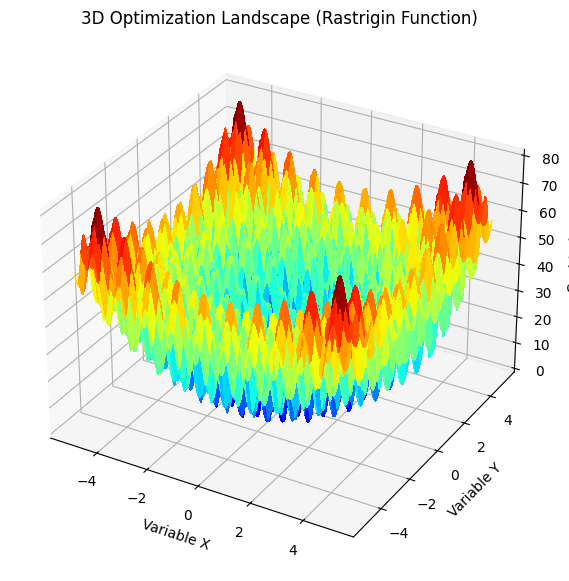

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Define the 2D Rastrigin function
def rastrigin_2d(X, Y):
    return 20 + (X**2 - 10 * np.cos(2 * np.pi * X)) + (Y**2 - 10 * np.cos(2 * np.pi * Y))

# 2. Create grid coordinates
x = np.linspace(-5.12, 5.12, 200)
y = np.linspace(-5.12, 5.12, 200)
X, Y = np.meshgrid(x, y)
Z = rastrigin_2d(X, Y)

# 3. Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Use 'jet' or 'turbo' colormap to perfectly match your example image style
surf = ax.plot_surface(X, Y, Z, cmap=cm.jet, linewidth=0, antialiased=False)

# 4. Adjust camera angle to match the perspective in your image
ax.view_init(elev=30, azim=-60)

# Clean up axes to emphasize the surface geometry
ax.set_title("3D Optimization Landscape (Rastrigin Function)")
ax.set_xlabel("Variable X")
ax.set_ylabel("Variable Y")
ax.set_zlabel("Cost Value")

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
from scipy.optimize import linear_sum_assignment

def generate_student_preferences(n_students, n_classes, max_score=10):
    """Generates a realistic student preference matrix with common popularity trends."""
    class_popularity = np.random.uniform(low=3.0, high=max_score - 2.0, size=n_classes)
    preferences = []
    for _ in range(n_students):
        student_noise = np.random.normal(loc=0.0, scale=3.0, size=n_classes)
        student_pref = np.clip(class_popularity + student_noise, 1, max_score)
        preferences.append(np.round(student_pref).astype(int))
    return np.array(preferences)

# ==========================================
# CONFIGURATION & SIMULATION RUN
# ==========================================
NUM_RUNS = 100
N_STUDENTS = 8
N_CLASSES = 8
MAX_SCORE = 10

records = []

for run_id in range(NUM_RUNS):
    prefs = generate_student_preferences(N_STUDENTS, N_CLASSES, MAX_SCORE)
    cost_matrix = MAX_SCORE - prefs
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    total_utility = prefs[row_ind, col_ind].sum()

    # Format the configuration text for the hover popup
    config_lines = []
    for student, cls in zip(row_ind, col_ind):
        config_lines.append(f"Student {student} ➔ Class {cls} (Score: {prefs[student, cls]})")

    # HTML <br> tags break the text into clean lines inside the Plotly tooltip
    hover_config_text = "<br>".join(config_lines)

    records.append({
        "Run ID": f"Run #{run_id}",
        "Total Utility": total_utility,
        "Configuration Details": hover_config_text
    })

# Convert data into a DataFrame for Plotly
df = pd.DataFrame(records)

# ==========================================
# CREATE INTERACTIVE PLOTLY CHART
# ==========================================
fig = px.histogram(
    df,
    x="Total Utility",
    title=f"Distribution of Collective Utility Over {NUM_RUNS} Simulation Runs",
    labels={"Total Utility": "Total Collective Utility Score", "count": "Number of Runs"},
    color_discrete_sequence=["#800080"], # Purple color matching the previous chart
    nbins=15,
    hover_data={
        "Total Utility": True,
        "Run ID": True,
        "Configuration Details": True  # Displays our custom text block
    }
)

# Customize layout styles to look clean and modern
fig.update_layout(
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Courier New" # Monospace font keeps the text perfectly aligned
    ),
    yaxis_title="Frequency Count",
    bargap=0.05
)

# Open the chart in your browser
fig.show()
